In [2]:
import pandas as pd
import numpy as np 
from datetime import datetime, timedelta 
np.random.seed(42)

In [4]:
n_customers = 5000
customer_ids = np.arange(100001,100001 + n_customers)

customers = pd.DataFrame({
    "customer_id": customer_ids,
    "age": np.random.randint(22, 66, n_customers),
    "gender": np.random.choice(["Male","Female"], n_customers),
    "region": np.random.choice(
        ["Ontarion", "Quebec", "British Columbia", "Alberta"],
        n_customers,
        p=[0.38,0.23,0.22,0.17]
    ),
    "employment_status": np.random.choice(
        ["Salaried", "Self-Employed", "Unemployed"],
        n_customers,
        p=[0.7, 0.25, 0.05]
    ),
    "income": np.random.normal(75000, 25000, n_customers).clip(25000, 200000).round(0),
    "customer_since": [
        datetime.now() - timedelta(days=np.random.randint(365, 3650))
        for _ in range(n_customers)
    ]
})

# Credit score Correlated with income

customers["credit_score"] = (
    550 + (customers["income"]/ 200000) * 300
    + np.random.normal(0, 30, n_customers)
).clip(300, 900).round(0)

customers.head()

        

,customer_id,age,gender,region,employment_status,income,customer_since,credit_score
0,100001,23,Female,Alberta,Salaried,84911.0,2018-05-03 17:11:38.081532,691.0
1,100002,37,Male,Ontarion,Salaried,86240.0,2019-10-02 17:11:38.081597,618.0
2,100003,25,Female,Quebec,Salaried,48841.0,2019-10-11 17:11:38.081631,614.0
3,100004,55,Male,Quebec,Salaried,89719.0,2021-07-01 17:11:38.081652,693.0
4,100005,26,Male,Ontarion,Salaried,136418.0,2018-12-06 17:11:38.081671,757.0


In [5]:
# STEP 2B: Accounts Table

account_rows = []
account_id = 200001

for _, row in customers.iterrows():
    n_accounts = np.random.choice([1, 2, 3], p=[0.4, 0.4, 0.2])
    
    for _ in range(n_accounts):
        acc_type = np.random.choice(
            ["savings", "credit_card", "loan"],
            p=[0.4, 0.4, 0.2]
        )
        
        if acc_type != "savings" and row["credit_score"] < 600:
            acc_type = "savings"
        
        credit_limit = None
        interest_rate = None
        
        if acc_type == "credit_card":
            credit_limit = np.random.choice([5000, 10000, 20000, 30000])
            interest_rate = round(np.random.uniform(15, 22), 2)
            balance = np.random.uniform(0.2, 0.9) * credit_limit
        
        elif acc_type == "loan":
            credit_limit = np.random.choice([20000, 50000, 100000])
            interest_rate = round(np.random.uniform(6, 12), 2)
            balance = np.random.uniform(0.4, 1.0) * credit_limit
        
        else:  # savings
            balance = np.random.uniform(500, 50000)
        
        account_rows.append([
            account_id,
            row["customer_id"],
            acc_type,
            datetime.now() - timedelta(days=np.random.randint(30, 3000)),
            interest_rate,
            credit_limit,
            round(balance, 2)
        ])
        
        account_id += 1

accounts = pd.DataFrame(
    account_rows,
    columns=[
        "account_id",
        "customer_id",
        "account_type",
        "open_date",
        "interest_rate",
        "credit_limit",
        "current_balance"
    ]
)

accounts.head()


,account_id,customer_id,account_type,open_date,interest_rate,credit_limit,current_balance
0,200001,100001,credit_card,2019-07-22 20:02:22.832943,16.55,20000.0,7787.18
1,200002,100002,loan,2020-02-17 20:02:22.834846,8.17,50000.0,28536.18
2,200003,100002,savings,2024-03-15 20:02:22.835041,NaN,NaN,13092.86
3,200004,100003,loan,2019-01-26 20:02:22.835584,9.59,100000.0,42830.26
4,200005,100004,loan,2023-03-07 20:02:22.836086,7.13,50000.0,38173.96


In [8]:
customers.to_csv(r"D:\python project files\bank profitbility\customers.csv", index=False)
accounts.to_csv(r"D:\python project files\bank profitbility\accounts.csv", index=False)

print("Customers & Accounts data generated successfully")

Customers & Accounts data generated successfully


In [43]:
# STEP 3: Transactions Table

transaction_rows = []
transaction_id = 300001

merchant_categories = [
    "Grocery", "Fuel", "Dining", "Travel",
    "E-commerce", "Utilities", "Healthcare",
    "Entertainment", "Salary", "Transfer"
]

for _, acc in accounts.iterrows():
    
    # Loans do not have daily transactions
    if acc["account_type"] == "loan":
        continue
    
    # Number of transactions per year
    if acc["account_type"] == "credit_card":
        n_txn = np.random.randint(80, 180)
    else:  # savings
        n_txn = np.random.randint(30, 90)
    
    for _ in range(n_txn):
        txn_date = datetime.now() - timedelta(days=np.random.randint(1, 365))
        
        if acc["account_type"] == "credit_card":
            txn_type = "debit"
            category = np.random.choice(
                merchant_categories[:-2],
                p=[0.18, 0.12, 0.16, 0.08, 0.18, 0.1, 0.08, 0.1]
            )
            amount = round(np.random.uniform(10, 500), 2)
        
        else:  # savings
            txn_type = np.random.choice(["credit", "debit"], p=[0.65, 0.35])
            
            if txn_type == "credit":
                category = np.random.choice(["Salary", "Transfer"], p=[0.7, 0.3])
                amount = round(np.random.uniform(1000, 6000), 2)
            else:
                category = np.random.choice(
                    merchant_categories[:-2],
                    p=[0.22, 0.15, 0.12, 0.05, 0.18, 0.15, 0.08, 0.05]
                )
                amount = round(np.random.uniform(20, 300), 2)
        
        transaction_rows.append([
            transaction_id,
            acc["account_id"],
            txn_date,
            amount,
            txn_type,
            category
        ])
        
        transaction_id += 1

transactions = pd.DataFrame(
    transaction_rows,
    columns=[
        "transaction_id",
        "account_id",
        "transaction_date",
        "amount",
        "transaction_type",
        "merchant_category"
    ]
)

transactions.head()

,transaction_id,account_id,transaction_date,amount,transaction_type,merchant_category
0,300001,200001,2025-05-15 16:55:54.575378,313.46,debit,Travel
1,300002,200001,2025-05-18 16:55:54.575729,188.73,debit,Grocery
2,300003,200001,2025-02-19 16:55:54.575904,194.59,debit,Utilities
3,300004,200001,2025-06-06 16:55:54.576055,348.35,debit,Fuel
4,300005,200001,2025-06-02 16:55:54.576198,263.60,debit,E-commerce


In [44]:
transactions.to_csv(r"D:\python project files\bank profitbility\transactions.csv", index=False)
print("Transctions data generated Sucessfully")

Transctions data generated Sucessfully


In [45]:
len(transactions)


662465

In [50]:
# step:4 Payments & Defaults Table

payment_rows = []

# Merge credit score into accounts
accounts_risk = accounts.merge(
    customers[["customer_id","credit_score"]],
    on="customer_id",
    how="left"
)

for _, acc in accounts_risk.iterrows():

    if acc["account_type"] not in ["credit_card","loan"]:
        continue

    # Monthly payments for last 12 months
    for m in range(12):
        due_date = datetime.now() - timedelta(days=30 * m)

        utilizaation = (
            acc["current_balance"] / acc["credit_limit"]
            if acc["credit_limit"] else 0 
        )

        # Default probability logic
        if acc["credit_score"] < 580:
            default_prob = 0.25
        elif acc["credit_score"] < 650:
            default_prob = 0.12
        elif acc["credit_score"] < 750:
            default_prob = 0.05
        else:
            default_prob = 0.02

        default_flag = np.random.rand() < default_prob

        if default_flag:
            days_late = np.random.randint(30, 120)
            amount_paid = np.random.uniform(0, 0.5)
        else:
            days_late = np.random.choice([0, 5, 10], p=[0.85, 0.1, 0.05])
            amount_paid = np.random.uniform(0.9, 1.0)

        amounnt_due = (
            acc["current_balance"] * 0.05
            if acc["account_type"] == "credit_card"
            else acc["credit_limit"] * 0.01
        )

        payment_rows.append([
            acc["account_id"],
            due_date,
            due_date + timedelta(days=int(days_late)),
            round(amount_due, 2),
            round(amount_due * amount_paid, 2),
            days_late,
            int(default_flag)
        ])

payments = pd.DataFrame(
    payment_rows,
    columns=[
        "account_id",
        "due_date",
        "payment_date",
        "amount_due",
        "amount_paid",
        "days_late",
        "default_flag"
    ]
)

payments.head()
        

    

,account_id,due_date,payment_date,amount_due,amount_paid,days_late,default_flag
0,200001,2026-01-06 14:35:32.415641,2026-01-06 14:35:32.415641,389.36,367.47,0,0
1,200001,2025-12-07 14:35:32.417034,2025-12-12 14:35:32.417034,389.36,381.42,5,0
2,200001,2025-11-07 14:35:32.417460,2025-11-07 14:35:32.417460,389.36,359.22,0,0
3,200001,2025-10-08 14:35:32.417780,2025-10-08 14:35:32.417780,389.36,374.32,0,0
4,200001,2025-09-08 14:35:32.417999,2025-09-08 14:35:32.417999,389.36,377.32,0,0


In [18]:
import numpy as np 
np.random.rand()

0.3796924479534909

In [52]:
payments.to_csv(r"D:\python project files\bank profitbility\payments.csv", index=False)
print("Payments & Defaults data generated sucessfully")

Payments & Defaults data generated sucessfully


In [62]:
len(payments)



60132

In [8]:
import sqlite3
conn = sqlite3.connect(r"D:\python project files\bank profitbility\data\sql\banking.db")
with open(r"D:\python project files\bank profitbility\sql\schema.sql","r") as f:
    conn.executescript(f.read())
conn.commit()
conn.close()

In [15]:
import sqlite3
import pandas as pd 
conn = sqlite3.connect(r"D:\python project files\bank profitbility\data\sql\banking.db")
pd.read_csv(r"D:\python project files\bank profitbility\data\Raw\customers.csv").to_sql("customers",conn,if_exists="append",index=False)
pd.read_csv(r"D:\python project files\bank profitbility\data\Raw\accounts.csv").to_sql("accounts",conn,if_exists="append",index=False)
pd.read_csv(r"D:\python project files\bank profitbility\data\Raw\transactions.csv").to_sql("transactions",conn,if_exists="append",index=False)
pd.read_csv(r"D:\python project files\bank profitbility\data\Raw\payments.csv").to_sql("payments",conn,if_exists="append",index=False)

print(pd.read_sql("select count(*) from customers", conn))
print(pd.read_sql("select count(*) from accounts", conn))
print(pd.read_sql("select count(*) from transactions", conn))
print(pd.read_sql("select count(*) from payments",conn))

conn.close()

   count(*)
0      5000
   count(*)
0      8954
   count(*)
0    662465
   count(*)
0     60132


In [68]:
import sqlite3
import pandas as pd 
conn = sqlite3.connect(r"D:\python project files\bank profitbility\data\sql\banking.db")
df = pd.read_sql("""
select
c.customer_id,
c.region,
sum(case when a.account_type = 'credit_card' and t.transaction_type = 'debit' then t.amount * 0.02
         when a.account_type = 'loan' then a.current_balance * (a.interest_rate/100)
         else 0 
         end) as total_revenue
         from customers c 
         join accounts a on c.customer_id = a.customer_id 
         left join transactions t on a.account_id = t.account_id
         group by c.customer_id
         """,conn)
conn.close()
df.head()

,customer_id,region,total_revenue
0,100001,Alberta,703.159000
1,100002,Ontarion,2331.405906
2,100003,Quebec,4107.421934
3,100004,Quebec,2721.803348
4,100005,Ontarion,5703.281156


In [69]:
import numpy as np 
import sqlite3
risk = pd.read_sql("""
select 
a.customer_id,
avg(p.days_late) as avg_days_late,
sum(p.default_flag) as total_defaults,
count(p.default_flag) as total_payment_records
from payments p 
join accounts a on p.account_id = a.account_id
group by a.customer_id
""",sqlite3.connect(r"D:\python project files\bank profitbility\data\sql\banking.db"))
df = df.merge(risk,on="customer_id",how="left")
df.fillna(0,inplace=True)


In [70]:
df["default_rate"] = np.where(
    df["total_payment_records"] > 0,
    df["total_defaults"]/df["total_payment_records"],0)
df["risk_adjusted_revenue"] = df["total_revenue"] * (1- df["default_rate"])

In [71]:
df['risk_segment'] = np.where(
    (df['avg_days_late'] > 10) | (df['total_defaults'] > 0),
    'High Risk',
    'Low Risk'
)

In [72]:
df['estimated_clv'] = df['total_revenue'] * 3

In [73]:
    df['customer_type'] = np.select([(df['estimated_clv'] >= df['estimated_clv'].median()) & (df['risk_segment'] == 'Low Risk'),
                                     (df['estimated_clv'] >= df['estimated_clv'].median()) & (df['risk_segment'] == 'High Risk')
                                    ],
                                    [ 'High value - safe',
                                      'High value - Risky'
                                    ],
                                    default = 'Low Value'
                                   )

In [74]:
df['early_warning'] = np.where(
    (df['avg_days_late'] > 5) & (df['total_defaults'] == 0),1,0)


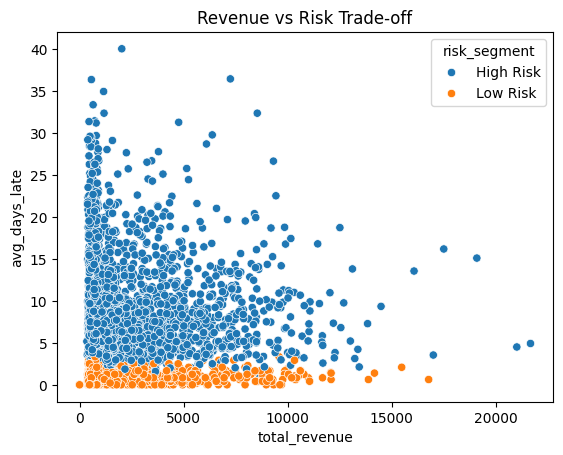

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df,x = 'total_revenue', y = 'avg_days_late', hue = 'risk_segment')
plt.title("Revenue vs Risk Trade-off")
plt.show()


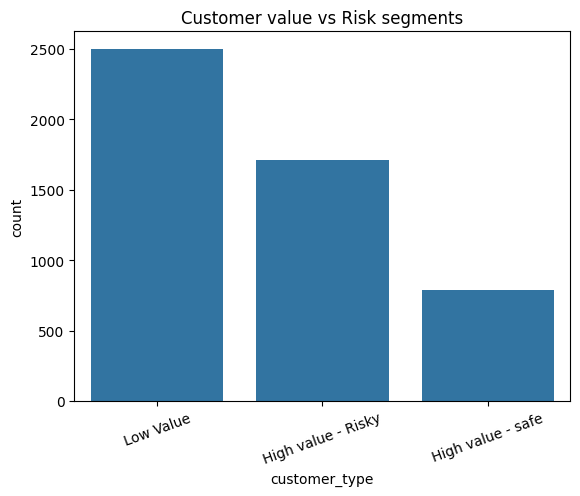

In [37]:
sns.countplot(data=df,x = 'customer_type')
plt.title("Customer value vs Risk segments")
plt.xticks(rotation=20)
plt.show()

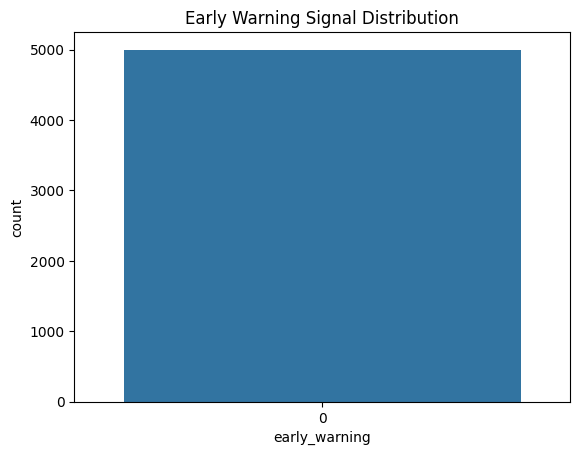

In [41]:
sns.countplot(data=df,x='early_warning')
plt.title("Early Warning Signal Distribution")
plt.show()